# Food Vision Project Using Transfer Learning
This project used **efficientB0V2** model on **Food101** dataset.

## Libraries

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

## Helper Functions

In [2]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Constatnts

In [3]:
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
INPUT_SIZE = 224

---

## Load Dataset

In [4]:
(train_data, test_data), ds_info = tfds.load(name="food101", # target dataset to get from TFDS.
                                             split=["train", "validation"], # what splits of data should we get, note: not all datasets have train, valid, test
                                             shuffle_files=True, # shuffle files on download.
                                             as_supervised=True, # download data in tuple format (sample, label), e.g. (image, label)
                                             with_info=True) # include dataset metadata, if tfds.load() returns tuple (data, ds_info).

### Features of the Food101 dataset

In [5]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

### Class Names of the Food101 dataset

In [6]:
class_names = ds_info.features['label'].names
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheesecake',
 'cheese_plate',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

### Sample Image from the Food101 dataset

In [7]:
sample_image = train_data.take(1)
for image, label in sample_image:
    print(f"""
      Image Shape = {image.shape}
      Image Dimensions = {image.ndim}
      Image Data Type = {image.dtype}
      Target Class = {label}
      Target Class Name = {class_names[label]}
    """)


      Image Shape = (512, 512, 3)
      Image Dimensions = 3
      Image Data Type = <dtype: 'uint8'>
      Target Class = 81
      Target Class Name = ramen
    


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

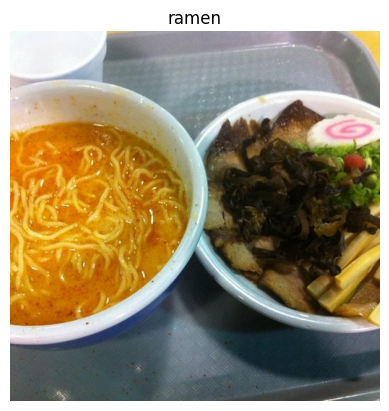

In [8]:
plt.imshow(image)
plt.title(class_names[label])
plt.axis(False)

---

## Preprocessing the Food101 dataset

In [9]:
def preprocess_img(image, label, img_shape=224):
    image = tf.keras.preprocessing.image.smart_resize(
        image,
        (img_shape, img_shape)
    )
    image = tf.keras.backend.cast(image, tf.float32)
    return image, label


In [10]:
train_data = (
    train_data
    .map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_data = (
    test_data
    .map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


---

## Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
], name="data_augmentation")

---

## Callbacks

### Tensorboard Callback

In [12]:
from helper_functions import create_tensorboard_callback

### Model Checkpoint

In [13]:
checkpoint_path = "model_checkpoints/cp..weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_acc",
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      verbose=0)

## Early Stopping

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", # watch the val loss metric
                                                  patience=3)

## learning rate reduction

In [15]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                 factor=0.2, # multiply the learning rate by 0.2 (reduce by 5x)
                                                 patience=2,
                                                 verbose=1, # print out when learning rate goes down
                                                 min_lr=1e-7)

---

## Setup mixed precision training

In [16]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy="mixed_float16")

---

## Building Model

### Base Model

In [17]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = True
for layer in base_model.layers[:-10]:
  layer.trainable = False

### Model

In [18]:
inputs = tf.keras.layers.Input(shape=INPUT_SHAPE, name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(len(class_names))(x)
outputs = tf.keras.layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)

model = tf.keras.Model(inputs, outputs)

## Compiling Model

In [19]:
model.compile(loss="sparse_categorical_crossentropy",
              metrics=["accuracy"],
              optimizer=tf.keras.optimizers.Adam())

## Model Summary

In [20]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,048,693 (23.07 MB)

 Trainable params: 711,061 (2.71 MB)

 Non-trainable params: 5,337,632 (20.36 MB)

## Fitting Model

In [21]:
hist = model.fit(train_data,
          epochs =3,
          steps_per_epoch=len(train_data),
          validation_data=test_data,
          validation_steps=int(0.15 * len(test_data)),
          callbacks=[create_tensorboard_callback("training_logs", "efficientnetb0v2"),
                     model_checkpoint,
                     early_stopping,
                     reduce_lr])

Saving TensorBoard log files to: training_logs/efficientnetb0v2/20260208-135619
Epoch 1/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.4460 - loss: 2.3392

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 956s 391ms/step - accuracy: 0.4460 - loss: 2.3390 - val_accuracy: 0.7198 - val_loss: 0.9807 - learning_rate: 0.0010
Epoch 2/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 386s 162ms/step - accuracy: 0.6281 - loss: 1.4458 - val_accuracy: 0.7500 - val_loss: 0.8913 - learning_rate: 0.0010
Epoch 3/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 373s 133ms/step - accuracy: 0.6650 - loss: 1.2781 - val_accuracy: 0.7664 - val_loss: 0.8302 - learning_rate: 0.0010


## Evaluating Model

In [22]:
loss, acc = model.evaluate(test_data)
print(f"""Model Accuracy = {acc}
          Model Loss = {loss}""")

790/790 ━━━━━━━━━━━━━━━━━━━━ 57s 71ms/step - accuracy: 0.7659 - loss: 0.8391
Model Accuracy = 0.7673267126083374
          Model Loss = 0.8357154726982117


## Model Prediction

In [23]:
pred_probs = model.predict(test_data, verbose=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 70ms/step


---

## Loss Curves

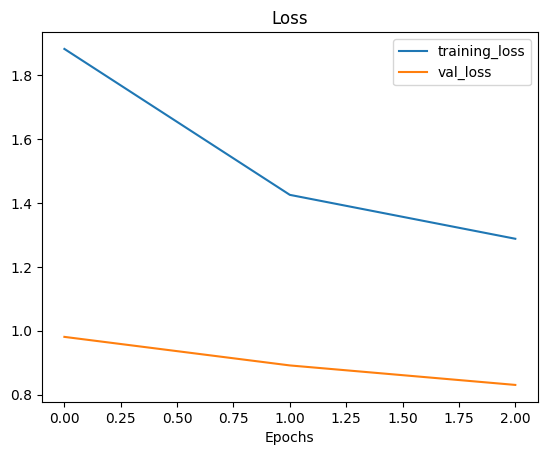

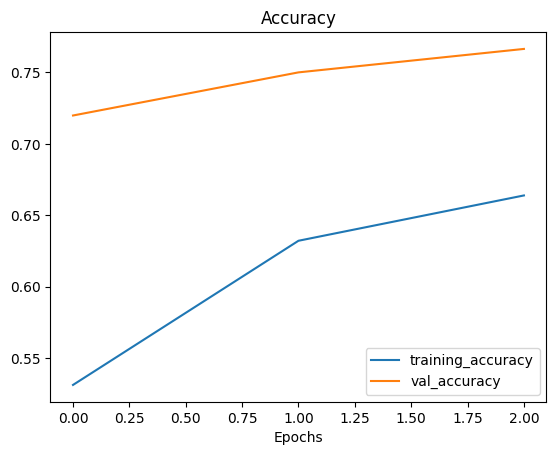

In [24]:
from helper_functions import plot_loss_curves
plot_loss_curves(hist)

---

## Confusion Matrix

In [25]:
y_labels = []
for images, labels in test_data:
    y_labels.extend(labels.numpy())
y_labels[:10]

[np.int64(78),
 np.int64(100),
 np.int64(79),
 np.int64(4),
 np.int64(37),
 np.int64(14),
 np.int64(42),
 np.int64(69),
 np.int64(30),
 np.int64(44)]

In [26]:
pred_classes = pred_probs.argmax(axis=1)

In [27]:
from helper_functions import make_confusion_matrix
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

---

## Save Model

In [28]:
model.save('efficientnetb0_food101_model.keras')

---

## Load Model

In [29]:
loaded_model = tf.keras.models.load_model('efficientnetb0_food101_model.keras')
loaded_model.load_weights(checkpoint_path)
loaded_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,470,821 (28.50 MB)

 Trainable params: 711,061 (2.71 MB)

 Non-trainable params: 5,337,632 (20.36 MB)

 Optimizer params: 1,422,128 (5.42 MB)

---